# Importing Libraries

In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(action = 'ignore')

# Load the Dataset

In [39]:
df = pd.read_csv('cars_clustering.csv')

In [45]:
df.shape, df.head()

((159, 16),
   manufact    model   sales  resale type   price engine_s horsepow wheelbas  \
 0    Acura  Integra  16.919   16.36    0    21.5      1.8      140    101.2   
 1    Acura       TL  39.384  19.875    0    28.4      3.2      225    108.1   
 2    Acura       CL  14.114  18.225    0  $null$      3.2      225    106.9   
 3    Acura       RL   8.588  29.725    0      42      3.5      210    114.6   
 4     Audi       A4  20.397  22.255    0   23.99      1.8      150    102.6   
 
   width length curb_wgt fuel_cap mpg lnsales  partition  
 0  67.3  172.4    2.639     13.2  28   2.828          0  
 1  70.3  192.9    3.517     17.2  25   3.673          0  
 2  70.6    192     3.47     17.2  26   2.647          0  
 3  71.4  196.6     3.85       18  22    2.15          0  
 4  68.2    178    2.998     16.4  27   3.015          0  )

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   manufact   157 non-null    object
 1   model      159 non-null    object
 2   sales      159 non-null    object
 3   resale     159 non-null    object
 4   type       159 non-null    object
 5   price      159 non-null    object
 6   engine_s   159 non-null    object
 7   horsepow   159 non-null    object
 8   wheelbas   159 non-null    object
 9   width      159 non-null    object
 10  length     159 non-null    object
 11  curb_wgt   159 non-null    object
 12  fuel_cap   159 non-null    object
 13  mpg        159 non-null    object
 14  lnsales    159 non-null    object
 15  partition  159 non-null    int64 
dtypes: int64(1), object(15)
memory usage: 20.0+ KB


# Data Preprocessing

In [52]:
# Replace non-numeric and missing values
df_cleaned = df.replace({'\$null\$': np.nan, '\$': ''}, regex = True)
df_cleaned = df_cleaned.drop(columns = ['manufact', 'model', 'lnsales', 'partition'])  # Drop non-numeric/categorical columns

# Convert all remaining columns to numeric
df_cleaned = df_cleaned.apply(pd.to_numeric, errors = 'coerce')

# Drop rows with missing values
df_cleaned = df_cleaned.dropna()

# Display the cleaned data
df_cleaned.head(), df_cleaned.shape

(    sales  resale  type  price  engine_s  horsepow  wheelbas  width  length  \
 0  16.919  16.360   0.0  21.50       1.8     140.0     101.2   67.3   172.4   
 1  39.384  19.875   0.0  28.40       3.2     225.0     108.1   70.3   192.9   
 3   8.588  29.725   0.0  42.00       3.5     210.0     114.6   71.4   196.6   
 4  20.397  22.255   0.0  23.99       1.8     150.0     102.6   68.2   178.0   
 5  18.780  23.555   0.0  33.95       2.8     200.0     108.7   76.1   192.0   
 
    curb_wgt  fuel_cap   mpg  
 0     2.639      13.2  28.0  
 1     3.517      17.2  25.0  
 3     3.850      18.0  22.0  
 4     2.998      16.4  27.0  
 5     3.561      18.5  22.0  ,
 (117, 12))

# Normalize the data and perform Agglomerative Clustering

In [55]:
# Normalize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cleaned)

In [57]:
# Perform hierarchical clustering with different linkage methods
linkage_methods = ['single', 'complete', 'average']
linkage_matrices = {method: linkage(scaled_data, method = method) for method in linkage_methods}

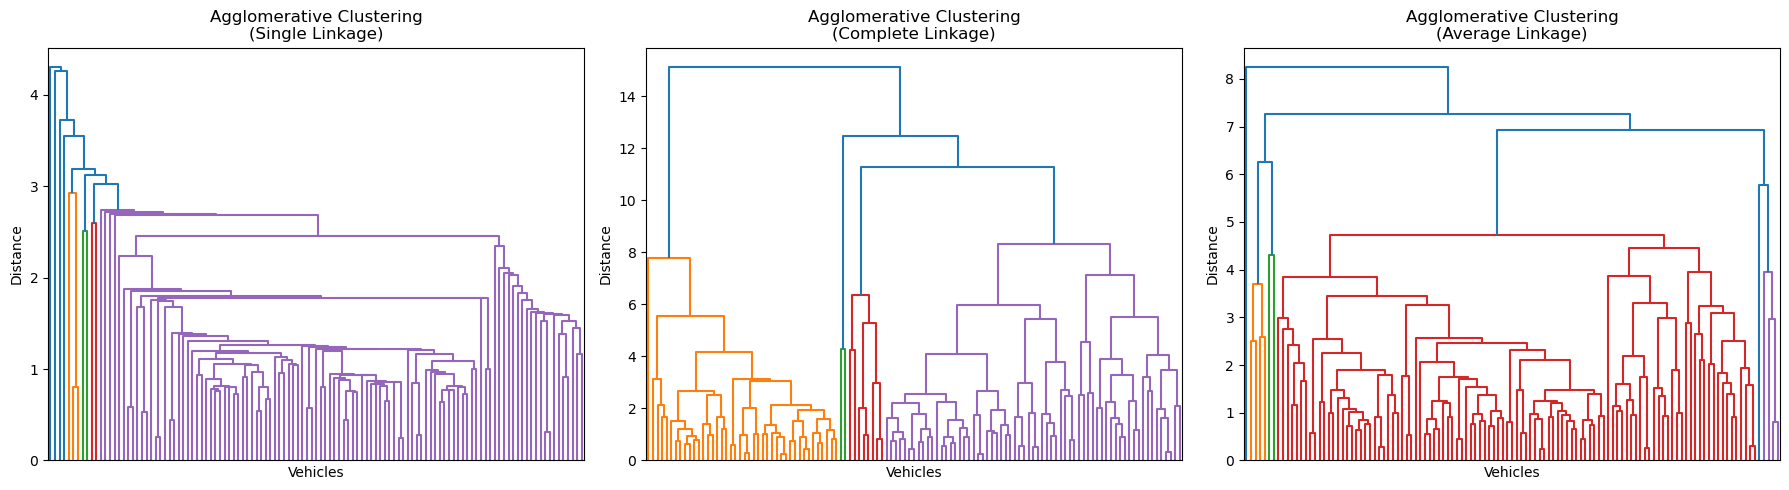

In [61]:
# Plot dendrograms
plt.figure(figsize = (18, 5))
for i, method in enumerate(linkage_methods):
    plt.subplot(1, 3, i + 1)
    dendrogram(linkage_matrices[method], no_labels=True)
    plt.title(f'Agglomerative Clustering\n({method.capitalize()} Linkage)')
    plt.xlabel('Vehicles')
    plt.ylabel('Distance')
plt.tight_layout()
plt.show()

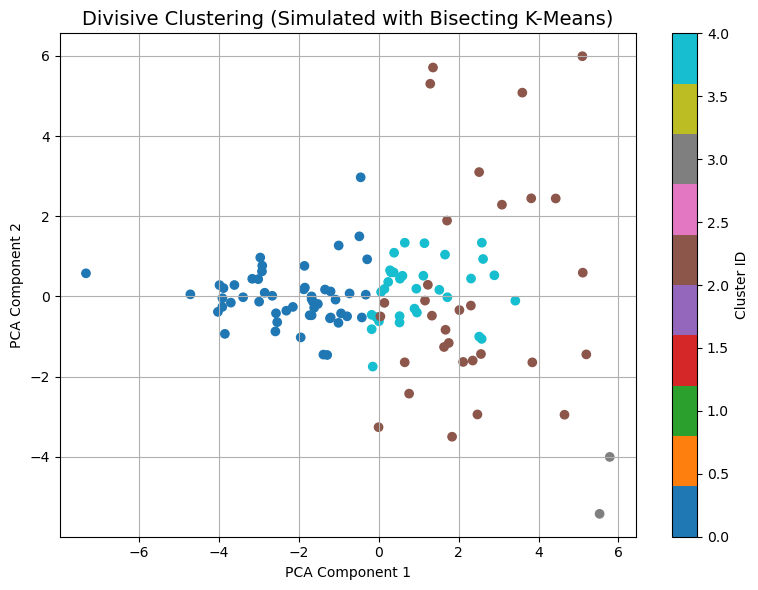

In [69]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fixed Bisecting K-Means (Divisive Clustering)
def bisecting_kmeans(data, max_clusters=5):
    clusters = [data]
    cluster_indices = [np.arange(data.shape[0])]
    labels = np.zeros(data.shape[0], dtype=int)

    for cluster_id in range(1, max_clusters):
        # Find the cluster with highest SSE
        sse_list = [np.sum((cluster - cluster.mean(axis=0)) ** 2) for cluster in clusters]
        idx_to_split = np.argmax(sse_list)
        cluster_to_split = clusters.pop(idx_to_split)
        indices_to_split = cluster_indices.pop(idx_to_split)

        # Apply k-means with k=2 to the selected cluster
        kmeans = KMeans(n_clusters=2, random_state=0).fit(cluster_to_split)
        split_labels = kmeans.labels_

        # Split the cluster and track their original indices
        cluster_0 = cluster_to_split[split_labels == 0]
        cluster_1 = cluster_to_split[split_labels == 1]
        indices_0 = indices_to_split[split_labels == 0]
        indices_1 = indices_to_split[split_labels == 1]

        # Add new clusters and indices
        clusters.extend([cluster_0, cluster_1])
        cluster_indices.extend([indices_0, indices_1])

        # Update labels
        labels[indices_0] = idx_to_split
        labels[indices_1] = cluster_id

    return labels

# Apply the bisecting k-means algorithm
divisive_labels = bisecting_kmeans(scaled_data, max_clusters=5)

# Visualize the clusters using PCA (2D)
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=divisive_labels, cmap='tab10')
plt.title("Divisive Clustering (Simulated with Bisecting K-Means)", fontsize=14)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.tight_layout()
plt.show()